# PoseBusters Parallel Pose Validation Pipeline

Validates docked poses from multiple docking methods using PoseBusters.
Supports AutoDock Vina, DiffDock, and EquiBind outputs.

# Imports & Configuration

In [12]:
import os
import re
import shutil
import subprocess
from pathlib import Path
from multiprocessing import Pool, cpu_count

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from posebusters import PoseBusters

# ============================================================================
# DIRECTORIES
# ============================================================================
wd = "/home/manndo/master_dev"

# Protein structures directory — PDB files here define available proteins
proteins_dir = wd + "/Orai"

# Docking result directories — keys are method names, values are paths
diffdock_poses_dir_large_ligands = wd + "/diffdock_results/ligands_sdf_large_complex"

docking_directories = {
    # "autodock": wd + "/docking_ready_mgltools/docking",
    # "diffdock": wd + "/diffdock_results",
    # "equibind_guided": wd + "/equibind_pocket_guided",
    # "equibind_exclusion": wd + "/equibind_spatial_exclusion_poses",
    # "equibind_docked_poses": wd + "/equibind_docked_poses_2",
    "diffdock": diffdock_poses_dir_large_ligands,
}

# ============================================================================
# POSEBUSTERS CONFIGURATION
# ============================================================================
CONFIG_MODE = "dock"         # "dock" (with protein) or "mol" (ligand only)
SAVE_INTERVAL = 100          # Checkpoint every N poses
OVERWRITE = False            # True = re-run all; False = resume
NUM_WORKERS = None           # None = use all CPU cores

# Output directories
output_base_dir = Path(wd) / "posebusters_results"
output_base_dir.mkdir(exist_ok=True)
output_dir = output_base_dir / CONFIG_MODE
output_dir.mkdir(exist_ok=True)
converted_dir = output_dir / "converted_pdbqt"
converted_dir.mkdir(exist_ok=True)

# Protein Discovery
Build a lookup from actual PDB files found in `proteins_dir`.

In [13]:
proteins_base = Path(proteins_dir)
all_protein_pdbs = sorted(proteins_base.glob("**/*.pdb"))

# Build stem → path mapping from every PDB file found
_protein_file_map: dict[str, str] = {}
for pdb in all_protein_pdbs:
    _protein_file_map[pdb.stem] = str(pdb)

print("=" * 80)
print("AVAILABLE PROTEIN PDB FILES")
print("=" * 80)
for stem, path in sorted(_protein_file_map.items()):
    print(f"  {stem}  →  {path}")
print(f"\nTotal: {len(_protein_file_map)} PDB files found in {proteins_base}")


def find_protein_file(protein_name: str) -> str | None:
    """Find the PDB file for a protein name using the discovered file map.

    Matching strategies (in order):
      1. Exact stem match
      2. Stem match with common suffixes stripped/added
      3. Substring containment (shortest filename wins)
      4. Normalized match (hyphens ↔ underscores, case-insensitive)
    """
    # 1. Exact match on stem
    if protein_name in _protein_file_map:
        return _protein_file_map[protein_name]

    # 2. Try common naming variants
    for suffix in ["", "_protein", "_clean", "_cleaned", "_receptor"]:
        candidate = protein_name + suffix
        if candidate in _protein_file_map:
            return _protein_file_map[candidate]
    # Also try stripping those suffixes from the query
    for suffix in ["_protein", "_clean", "_cleaned", "_receptor"]:
        if protein_name.endswith(suffix):
            stripped = protein_name[: -len(suffix)]
            if stripped in _protein_file_map:
                return _protein_file_map[stripped]

    # 3. Substring containment — prefer shortest stem
    matches = [
        (stem, path)
        for stem, path in _protein_file_map.items()
        if protein_name.lower() in stem.lower()
    ]
    if matches:
        matches.sort(key=lambda t: len(t[0]))
        return matches[0][1]

    # 4. Normalized (hyphens/underscores, case-insensitive)
    norm = protein_name.replace("-", "_").lower()
    for stem, path in _protein_file_map.items():
        if stem.replace("-", "_").lower() == norm:
            return path
    for stem, path in _protein_file_map.items():
        if norm in stem.replace("-", "_").lower():
            return path

    return None

AVAILABLE PROTEIN PDB FILES
  Orai1WT-MDSnap-Fr300  →  /home/manndo/master_dev/Orai/stroed/Orai1WT-MDSnap-Fr300.pdb
  Orai1WT-MDSnap-Fr300_cleaned  →  /home/manndo/master_dev/Orai/Orai1WT-MDSnap-Fr300_cleaned.pdb
  Orai1WT-MDSnap-Fr400  →  /home/manndo/master_dev/Orai/stroed/Orai1WT-MDSnap-Fr400.pdb
  Orai1WT-MDSnap-Fr400_cleaned  →  /home/manndo/master_dev/Orai/Orai1WT-MDSnap-Fr400_cleaned.pdb
  Orai1WT-MDSnap-Fr499  →  /home/manndo/master_dev/Orai/stroed/Orai1WT-MDSnap-Fr499.pdb
  Orai1WT-MDSnap-Fr499_cleaned  →  /home/manndo/master_dev/Orai/Orai1WT-MDSnap-Fr499_cleaned.pdb
  Orai1WT-START-Fr0  →  /home/manndo/master_dev/Orai/stroed/Orai1WT-START-Fr0.pdb
  Orai1WT-START-Fr0_cleaned  →  /home/manndo/master_dev/Orai/Orai1WT-START-Fr0_cleaned.pdb

Total: 8 PDB files found in /home/manndo/master_dev/Orai


# Shared Helper Functions

In [14]:
# ============================================================================
# TEST-COLUMN DETECTION  (used by Results and Graphs cells)
# ============================================================================

# Columns that are never PoseBusters boolean tests
_METADATA_COLS = {
    "file_path", "filepath", "file", "path", "sdf_file", "sdf_path",
    "method", "docking_method", "protein", "ligand", "pose_rank", "rank",
    "molecule", "mol_name", "name", "complex", "protein_path", "ligand_path",
    "mol_pred", "mol_true", "mol_cond",
}

# Numeric / always-failing columns to exclude from test evaluation
_EXCLUDE_COLS = {
    "mol_true_loaded", "mol_cond_loaded",
    "number_short_outlier_bonds", "number_long_outlier_bonds",
    "number_outlier_angles", "number_clashes",
    "number_non-aromatic_rings_pass", "number_aromatic_rings_pass",
    "number_non-aromatic_rings_checked", "number_aromatic_rings_checked",
    "number_double_bonds_checked", "number_double_bonds_pass",
    "number_valid_bonds", "number_valid_angles", "number_valid_noncov_pairs",
    "number_noncov_pairs", "number_bonds", "number_angles",
    "num_h_added",
    "not_too_far_away_organic_cofactors",      # always fails (not in PDB)
    "not_too_far_away_inorganic_cofactors",    # always fails (not in PDB)
    "not_too_far_away_waters",                 # always fails (not in PDB)
}


def identify_test_columns(df: pd.DataFrame) -> list[str]:
    """Return the list of boolean PoseBusters test columns in *df*."""
    test_cols = []
    for col in df.columns:
        cl = col.lower().strip()
        if cl in _METADATA_COLS or col in _EXCLUDE_COLS or cl in _EXCLUDE_COLS:
            continue
        if cl.startswith("number_") or cl.startswith("num_"):
            continue
        unique_vals = set(df[col].dropna().unique())
        if unique_vals.issubset({True, False, 1, 0, 1.0, 0.0, "True", "False", "true", "false"}):
            test_cols.append(col)
    if not test_cols:
        test_cols = [c for c in df.columns if df[c].dtype == bool]
    return test_cols


def coerce_test_cols_to_bool(df: pd.DataFrame, test_cols: list[str]) -> None:
    """Convert string-encoded booleans to actual bool dtype in-place."""
    _map = {"True": True, "true": True, "False": False, "false": False}
    for tc in test_cols:
        if df[tc].dtype == object:
            df[tc] = df[tc].map(_map)
        df[tc] = df[tc].astype(bool)


# ============================================================================
# POSE ROW COLLECTORS  —  one per docking method
# Each returns a list of row-dicts with keys:
#   docking_tool, protein, ligand, file_path, pose_count
# ============================================================================

def _collect_autodock_rows(poses_dir: str) -> list[dict]:
    """Collect rows from AutoDock Vina PDBQT outputs."""
    rows = []
    base_path = Path(poses_dir)
    for pdbqt_file in base_path.glob("*_vina_out.pdbqt"):
        stem = pdbqt_file.stem.replace("_vina_out", "")
        parts = stem.split("__")
        if len(parts) == 2:
            protein, ligand = parts
            with open(pdbqt_file, "r") as f:
                pose_count = f.read().count("MODEL") or 1
            rows.append({
                "docking_tool": "autodock",
                "protein": protein,
                "ligand": ligand,
                "file_path": str(pdbqt_file),
                "pose_count": pose_count,
            })
    return rows


def _collect_diffdock_rows(poses_dir: str) -> list[dict]:
    """Collect rows from DiffDock SDF subdirectories."""
    rows = []
    base_path = Path(poses_dir)
    skip_names = {"prepared_proteins", "converted_pdbqt", "prepared_ligands", "Orai"}
    for subdir in base_path.iterdir():
        if not subdir.is_dir():
            continue
        if "_ligand__" in subdir.name or subdir.name in skip_names:
            continue
        parts = subdir.name.split("__")
        if len(parts) == 2:
            ligand, protein = parts
            pose_count = len(list(subdir.glob("**/*.sdf")))
            if pose_count > 0:
                rows.append({
                    "docking_tool": "diffdock",
                    "protein": protein,
                    "ligand": ligand,
                    "file_path": str(subdir),
                    "pose_count": pose_count,
                })
    return rows


def _collect_equibind_rows(poses_dir: str) -> list[dict]:
    """Collect rows from EquiBind SDF outputs (flat or spatial_sites layout)."""
    rows = []
    base_path = Path(poses_dir)
    for subdir in base_path.iterdir():
        if not subdir.is_dir() or "_pymol" in subdir.name:
            continue
        dir_name = subdir.name
        dir_clean = dir_name.replace("_spatial_sites", "") if dir_name.endswith("_spatial_sites") else dir_name
        parts = dir_clean.split("__")
        if len(parts) == 2:
            ligand, protein = parts
            pose_count = len(list(subdir.glob("**/*.sdf")))
            if pose_count > 0:
                rows.append({
                    "docking_tool": "equibind",
                    "protein": protein,
                    "ligand": ligand,
                    "file_path": str(subdir),
                    "pose_count": pose_count,
                })
    return rows


# Single registry: method key → row collector
ROW_COLLECTORS = {
    "autodock": _collect_autodock_rows,
    "diffdock": _collect_diffdock_rows,
    "equibind_guided": _collect_equibind_rows,
    "equibind_exclusion": _collect_equibind_rows,
    "equibind_docked_poses": _collect_equibind_rows,
}


# ============================================================================
# POSE-FILE COLLECTORS  —  expand a single row into per-SDF pose dicts
# Each returns a list of dicts with keys:
#   method, protein, ligand, pose_file, pose_name, file_format
# ============================================================================

def _expand_autodock_poses(row: dict, conv_dir: Path) -> list[dict]:
    """Expand an AutoDock row into individual per-model SDF pose dicts."""
    file_path = Path(row["file_path"])
    if not file_path.exists() or file_path.suffix != ".pdbqt":
        return []
    print(f"  Converting {file_path.name} to SDF...")
    sdf_files = _convert_pdbqt_to_sdf(str(file_path), conv_dir)
    poses = []
    for sdf_file in sdf_files:
        sdf_path = Path(sdf_file)
        model_num = sdf_path.stem.split("_model")[-1] if "_model" in sdf_path.stem else "1"
        poses.append({
            "method": row["docking_tool"],
            "protein": row["protein"],
            "ligand": row["ligand"],
            "pose_file": sdf_file,
            "pose_name": f"{row['protein']}__{row['ligand']}_pose{model_num}",
            "file_format": "sdf",
        })
    return poses


def _expand_diffdock_poses(row: dict, _conv_dir: Path) -> list[dict]:
    """Expand a DiffDock row into individual per-SDF pose dicts."""
    file_path = Path(row["file_path"])
    if not file_path.is_dir():
        return []
    poses = []
    for sdf_file in sorted(file_path.glob("**/*.sdf")):
        confidence = None
        if "confidence" in sdf_file.stem.lower():
            m = re.search(r"confidence[_-]?([\d.]+)", sdf_file.stem, re.IGNORECASE)
            if m:
                try:
                    confidence = float(m.group(1))
                except ValueError:
                    pass
        try:
            rel = str(sdf_file.relative_to(file_path))
        except ValueError:
            rel = sdf_file.name
        info = {
            "method": row["docking_tool"],
            "protein": row["protein"],
            "ligand": row["ligand"],
            "pose_file": str(sdf_file),
            "pose_name": f"{row['ligand']}__{row['protein']}/{rel}",
            "file_format": "sdf",
        }
        if confidence is not None:
            info["confidence"] = confidence
        poses.append(info)
    return poses


def _expand_equibind_poses(row: dict, _conv_dir: Path) -> list[dict]:
    """Expand an EquiBind row into individual per-SDF pose dicts."""
    file_path = Path(row["file_path"])
    if not file_path.is_dir():
        return []
    poses = []
    for sdf_file in sorted(file_path.glob("**/*.sdf")):
        try:
            rel = str(sdf_file.relative_to(file_path))
        except ValueError:
            rel = sdf_file.name
        poses.append({
            "method": row["docking_tool"],
            "protein": row["protein"],
            "ligand": row["ligand"],
            "pose_file": str(sdf_file),
            "pose_name": f"{row['ligand']}__{row['protein']}/{rel}",
            "file_format": "sdf",
        })
    return poses


# Single registry: method key → pose-file expander
POSE_EXPANDERS = {
    "autodock": _expand_autodock_poses,
    "diffdock": _expand_diffdock_poses,
    "equibind_guided": _expand_equibind_poses,
    "equibind_exclusion": _expand_equibind_poses,
    "equibind_docked_poses": _expand_equibind_poses,
}


# ============================================================================
# PDBQT → SDF CONVERSION (AutoDock only)
# ============================================================================

def _split_pdbqt_models(pdbqt_file: str) -> list[str]:
    """Split a multi-model PDBQT file into separate model blocks."""
    with open(pdbqt_file, "r") as f:
        content = f.read()
    models, current, in_model = [], [], False
    for line in content.split("\n"):
        if line.startswith("MODEL"):
            in_model = True
            current = [line]
        elif line.startswith("ENDMDL"):
            current.append(line)
            models.append("\n".join(current))
            current, in_model = [], False
        elif in_model:
            current.append(line)
    if not models and content.strip():
        models = [content]
    return models


def _convert_pdbqt_to_sdf(pdbqt_file: str, out_dir: Path) -> list[str]:
    """Convert a multi-pose PDBQT to individual SDF files.

    Uses RDKit bond-order template assignment when the original ligand SDF
    can be found, with obabel and plain-RDKit fallbacks.
    """
    from rdkit import Chem
    from rdkit.Chem import AllChem

    pdbqt_path = Path(pdbqt_file)
    base_name = pdbqt_path.stem
    models = _split_pdbqt_models(pdbqt_file)
    if not models:
        print(f"  Warning: No models found in {pdbqt_file}")
        return []

    # Try to locate original ligand SDF as bond-order template
    stem_clean = base_name.replace("_vina_out", "")
    parts = stem_clean.split("__")
    template_mol = None
    if len(parts) == 2:
        _protein_name, ligand_name = parts
        search_dirs = [
            Path(wd) / d for d in [
                "ligands", "Ligands",
                "docking_ready_mgltools", "docking_ready_mgltools/ligands", "",
            ]
        ]
        for sdir in search_dirs:
            if not sdir.exists():
                continue
            for pat in [f"{ligand_name}.sdf", f"{ligand_name}_*.sdf", f"*{ligand_name}*.sdf"]:
                for match in sdir.glob(pat):
                    try:
                        template_mol = Chem.MolFromMolFile(str(match), removeHs=True, sanitize=True)
                        if template_mol is not None:
                            print(f"    Using bond-order template: {match.name}")
                            break
                    except Exception:
                        pass
                if template_mol is not None:
                    break
            if template_mol is not None:
                break

    converted = []
    for i, model_content in enumerate(models, start=1):
        output_sdf = out_dir / f"{base_name}_model{i}.sdf"
        if output_sdf.exists():
            converted.append(str(output_sdf))
            continue

        temp_pdbqt = out_dir / f"{base_name}_model{i}.pdbqt"
        temp_pdb = out_dir / f"{base_name}_model{i}.pdb"
        with open(temp_pdbqt, "w") as f:
            f.write(model_content)

        mol_final = None

        # Strategy 1: obabel PDBQT→PDB → RDKit + template
        if template_mol is not None:
            try:
                res = subprocess.run(
                    ["obabel", str(temp_pdbqt), "-O", str(temp_pdb)],
                    capture_output=True, text=True,
                )
                if res.returncode == 0 and temp_pdb.exists():
                    raw = Chem.MolFromPDBFile(str(temp_pdb), removeHs=True, sanitize=False)
                    if raw is not None:
                        try:
                            mol_final = AllChem.AssignBondOrdersFromTemplate(template_mol, raw)
                            Chem.SanitizeMol(mol_final)
                        except Exception as e:
                            print(f"    Template assignment failed for model {i}: {e}")
                            mol_final = None
                if temp_pdb.exists():
                    temp_pdb.unlink()
            except FileNotFoundError:
                pass

        # Strategy 2: obabel PDBQT→SDF directly
        if mol_final is None:
            try:
                res = subprocess.run(
                    ["obabel", str(temp_pdbqt), "-O", str(output_sdf)],
                    capture_output=True, text=True,
                )
                if res.returncode == 0 and output_sdf.exists():
                    if template_mol is not None:
                        try:
                            raw = Chem.MolFromMolFile(str(output_sdf), removeHs=True, sanitize=False)
                            if raw is not None:
                                mol_final = AllChem.AssignBondOrdersFromTemplate(template_mol, raw)
                                Chem.SanitizeMol(mol_final)
                        except Exception:
                            converted.append(str(output_sdf))
                            temp_pdbqt.unlink(missing_ok=True)
                            continue
                    else:
                        converted.append(str(output_sdf))
                        temp_pdbqt.unlink(missing_ok=True)
                        continue
            except FileNotFoundError:
                try:
                    raw = Chem.MolFromPDBFile(str(temp_pdbqt), removeHs=True, sanitize=False)
                    if raw is not None and template_mol is not None:
                        mol_final = AllChem.AssignBondOrdersFromTemplate(template_mol, raw)
                        Chem.SanitizeMol(mol_final)
                    elif raw is not None:
                        try:
                            Chem.SanitizeMol(raw)
                        except Exception:
                            pass
                        mol_final = raw
                except Exception as e:
                    print(f"    RDKit fallback failed for model {i}: {e}")

        if mol_final is not None:
            writer = Chem.SDWriter(str(output_sdf))
            writer.write(mol_final)
            writer.close()
            if output_sdf.exists():
                converted.append(str(output_sdf))
        elif not output_sdf.exists():
            print(f"    Warning: Could not convert model {i} from {pdbqt_path.name}")

        temp_pdbqt.unlink(missing_ok=True)

    return converted


def collect_all_pose_files(filtered_df: pd.DataFrame) -> list[dict]:
    """Expand every row in *filtered_df* into individual pose-file dicts."""
    all_poses = []
    for _, row in filtered_df.iterrows():
        expander = POSE_EXPANDERS.get(row["docking_tool"])
        if expander is None:
            print(f"  WARNING: No pose expander for '{row['docking_tool']}', skipping.")
            continue
        all_poses.extend(expander(row.to_dict(), converted_dir))
    return all_poses

# Pose Discovery & Overview

In [15]:
# ============================================================================
# Collect rows from all configured docking methods
# ============================================================================
print("=" * 100)
print("DOCKING POSES OVERVIEW")
print("=" * 100)
print("\nCollecting pose counts from all docking methods...\n")

all_rows: list[dict] = []
method_dfs: dict[str, pd.DataFrame] = {}

for method_key, poses_dir in docking_directories.items():
    collector = ROW_COLLECTORS.get(method_key)
    if collector is None:
        print(f"  WARNING: No row collector for '{method_key}', skipping.")
        continue
    if not Path(poses_dir).exists():
        print(f"  WARNING: Directory not found for '{method_key}': {poses_dir}, skipping.")
        continue

    method_rows = collector(poses_dir)
    for r in method_rows:
        r["docking_tool"] = method_key  # normalise tag to dict key
    all_rows.extend(method_rows)

    # Build per-method summary DataFrame for the overview table
    df_m = pd.DataFrame(method_rows)
    if not df_m.empty:
        col_name = method_key.replace(" ", "_").title()
        summary = df_m.groupby(["protein", "ligand"])["pose_count"].sum().reset_index()
        summary.columns = ["Protein", "Ligand", col_name]
        method_dfs[col_name] = summary
    print(f"  {method_key}: {len(method_rows)} protein-ligand combinations")

# Merge into overview table
df_combined = pd.DataFrame()
for col_name, df_m in method_dfs.items():
    if df_combined.empty:
        df_combined = df_m
    else:
        df_combined = df_combined.merge(df_m, on=["Protein", "Ligand"], how="outer")

if not df_combined.empty:
    method_cols = [c for c in df_combined.columns if c not in ("Protein", "Ligand")]
    df_combined = df_combined.fillna(0)
    for col in method_cols:
        df_combined[col] = df_combined[col].astype(int)
    df_combined["Total"] = df_combined[method_cols].sum(axis=1)
    df_combined = df_combined.sort_values(["Protein", "Ligand"])

    print("\n" + "=" * 100)
    print("POSE COUNTS BY PROTEIN-LIGAND COMBINATION")
    print("=" * 100)
    print(df_combined.to_string(index=False))

    print("\n" + "=" * 100)
    print("SUMMARY STATISTICS")
    print("=" * 100)
    print(f"\nTotal unique protein-ligand combinations: {len(df_combined)}")
    print(f"\nTotal poses by method:")
    for col in method_cols:
        print(f"  {col}: {df_combined[col].sum():,} poses")
    print(f"  Combined Total: {df_combined['Total'].sum():,} poses")
    print(f"\nUnique proteins: {df_combined['Protein'].nunique()}")
    print(f"Unique ligands: {df_combined['Ligand'].nunique()}")

    print("\n" + "-" * 100)
    print("POSES BY LIGAND")
    print("-" * 100)
    print(df_combined.groupby("Ligand")[method_cols + ["Total"]].sum().to_string())

    print("\n" + "-" * 100)
    print("POSES BY PROTEIN")
    print("-" * 100)
    print(df_combined.groupby("Protein")[method_cols + ["Total"]].sum().to_string())

    output_file = output_base_dir / "pose_counts_overview.csv"
    df_combined.to_csv(output_file, index=False)
    print(f"\n{'=' * 100}\nTable saved to: {output_file}\n{'=' * 100}")
else:
    print("\nNo docking results found!")

DOCKING POSES OVERVIEW


  diffdock: 12 protein-ligand combinations

POSE COUNTS BY PROTEIN-LIGAND COMBINATION
                     Protein    Ligand  Diffdock  Total
Orai1WT-MDSnap-Fr300_cleaned 017_ideal         6      6
Orai1WT-MDSnap-Fr300_cleaned 032_ideal         6      6
Orai1WT-MDSnap-Fr300_cleaned 07J_ideal         6      6
Orai1WT-MDSnap-Fr300_cleaned 08Y_ideal         6      6
Orai1WT-MDSnap-Fr300_cleaned 09L_ideal         6      6
Orai1WT-MDSnap-Fr300_cleaned 0LI_ideal         6      6
Orai1WT-MDSnap-Fr300_cleaned 0RI_ideal         6      6
Orai1WT-MDSnap-Fr300_cleaned 0WM_ideal         6      6
Orai1WT-MDSnap-Fr300_cleaned 117_ideal         6      6
Orai1WT-MDSnap-Fr300_cleaned 15M_ideal         6      6
Orai1WT-MDSnap-Fr300_cleaned 1C9_ideal         6      6
Orai1WT-MDSnap-Fr300_cleaned 1E8_ideal         6      6

SUMMARY STATISTICS

Total unique protein-ligand combinations: 12

Total poses by method:
  Diffdock: 72 poses
  Combined Total: 72 poses

Unique proteins: 1
Uni

In [16]:
# ============================================================================
# Build filtered_poses_df  &  keep only combos present in ALL methods
# ============================================================================
filtered_poses_df = pd.DataFrame(all_rows)
print(f"Total entries: {len(filtered_poses_df)}")
if not filtered_poses_df.empty:
    print(f"Methods found: {filtered_poses_df['docking_tool'].unique().tolist()}")

if not filtered_poses_df.empty:
    combos_by_method = {}
    for method in filtered_poses_df["docking_tool"].unique():
        mdf = filtered_poses_df[filtered_poses_df["docking_tool"] == method]
        combos_by_method[method] = set(zip(mdf["protein"], mdf["ligand"]))

    print("=" * 100)
    print("FILTERING: Keep Only Protein-Ligand Combinations in ALL Methods")
    print("=" * 100)
    for method, combos in combos_by_method.items():
        print(f"  {method}: {len(combos)} combinations")

    all_combo_sets = list(combos_by_method.values())
    common_combos = all_combo_sets[0]
    for s in all_combo_sets[1:]:
        common_combos = common_combos.intersection(s)

    print(f"\nProtein-ligand combinations in ALL methods: {len(common_combos)}")

    if common_combos:
        for protein, ligand in sorted(common_combos):
            print(f"  {protein} + {ligand}")

        filtered_poses_df = filtered_poses_df[
            filtered_poses_df.apply(
                lambda row: (row["protein"], row["ligand"]) in common_combos, axis=1
            )
        ].copy()

        print(f"\n{'-' * 100}")
        print("FILTERED SUBSET")
        print(f"{'-' * 100}")
        for method in filtered_poses_df["docking_tool"].unique():
            mdf = filtered_poses_df[filtered_poses_df["docking_tool"] == method]
            print(f"  {method}: {len(mdf)} combinations, {mdf['pose_count'].sum():,} poses")

        # Detailed summary
        methods_in_df = sorted(filtered_poses_df["docking_tool"].unique())
        header = f"{'Protein':<35} {'Ligand':<30}" + "".join(f" {m:>15}" for m in methods_in_df) + f" {'Total':>10}"
        print(f"\n{header}\n" + "-" * len(header))
        grand_totals = {m: 0 for m in methods_in_df}
        grand_all = 0
        for protein, ligand in sorted(common_combos):
            row_str = f"{protein:<35} {ligand:<30}"
            row_total = 0
            for m in methods_in_df:
                cnt = filtered_poses_df[
                    (filtered_poses_df["protein"] == protein)
                    & (filtered_poses_df["ligand"] == ligand)
                    & (filtered_poses_df["docking_tool"] == m)
                ]["pose_count"].sum()
                row_str += f" {cnt:>15,}"
                row_total += cnt
                grand_totals[m] += cnt
            row_str += f" {row_total:>10,}"
            grand_all += row_total
            print(row_str)
        print("-" * len(header))
        totals_str = f"{'TOTAL':<35} {'':<30}"
        for m in methods_in_df:
            totals_str += f" {grand_totals[m]:>15,}"
        totals_str += f" {grand_all:>10,}"
        print(totals_str)
        print(f"\nFinal filtered_poses_df shape: {filtered_poses_df.shape}")
    else:
        print("\nWARNING: No combinations found in all methods!")
else:
    print("filtered_poses_df is empty. Check docking_directories paths.")

Total entries: 12
Methods found: ['diffdock']
FILTERING: Keep Only Protein-Ligand Combinations in ALL Methods
  diffdock: 12 combinations

Protein-ligand combinations in ALL methods: 12
  Orai1WT-MDSnap-Fr300_cleaned + 017_ideal
  Orai1WT-MDSnap-Fr300_cleaned + 032_ideal
  Orai1WT-MDSnap-Fr300_cleaned + 07J_ideal
  Orai1WT-MDSnap-Fr300_cleaned + 08Y_ideal
  Orai1WT-MDSnap-Fr300_cleaned + 09L_ideal
  Orai1WT-MDSnap-Fr300_cleaned + 0LI_ideal
  Orai1WT-MDSnap-Fr300_cleaned + 0RI_ideal
  Orai1WT-MDSnap-Fr300_cleaned + 0WM_ideal
  Orai1WT-MDSnap-Fr300_cleaned + 117_ideal
  Orai1WT-MDSnap-Fr300_cleaned + 15M_ideal
  Orai1WT-MDSnap-Fr300_cleaned + 1C9_ideal
  Orai1WT-MDSnap-Fr300_cleaned + 1E8_ideal

----------------------------------------------------------------------------------------------------
FILTERED SUBSET
----------------------------------------------------------------------------------------------------
  diffdock: 12 combinations, 72 poses

Protein                             Liga

In [17]:
# ============================================================================
# Resolve protein PDB files for every protein in the filtered set
# ============================================================================
_protein_file_cache: dict[str, str | None] = {}

print("-" * 80)
print("PROTEIN FILE RESOLUTION")
print("-" * 80)
if not filtered_poses_df.empty:
    for pname in sorted(filtered_poses_df["protein"].unique()):
        pfile = find_protein_file(pname)
        _protein_file_cache[pname] = pfile
        status = f"✓ {Path(pfile).name}" if pfile else "✗ NOT FOUND"
        print(f"  {pname}: {status}")

    n_found = sum(1 for v in _protein_file_cache.values() if v)
    n_missing = sum(1 for v in _protein_file_cache.values() if not v)
    print(f"\n  Resolved: {n_found}/{len(_protein_file_cache)} proteins")
    if n_missing:
        print(f"  WARNING: {n_missing} proteins have no PDB — will fall back to 'mol' mode")

--------------------------------------------------------------------------------
PROTEIN FILE RESOLUTION
--------------------------------------------------------------------------------
  Orai1WT-MDSnap-Fr300_cleaned: ✓ Orai1WT-MDSnap-Fr300_cleaned.pdb

  Resolved: 1/1 proteins


# PoseBusters Parallel Validation

In [18]:
# ============================================================================
# PARALLEL WORKER FUNCTIONS
# ============================================================================
_worker_buster_dock = None
_worker_buster_mol = None
_worker_protein_cache = None
_worker_config_mode = None


def _init_worker(config_mode, protein_cache):
    """Initialise PoseBusters instances once per worker process."""
    global _worker_buster_dock, _worker_buster_mol, _worker_protein_cache, _worker_config_mode
    from posebusters import PoseBusters

    _worker_config_mode = config_mode
    _worker_protein_cache = protein_cache or {}
    if config_mode == "dock":
        _worker_buster_dock = PoseBusters(config="dock")
    _worker_buster_mol = PoseBusters(config="mol")


def _process_single_pose(pose_info):
    """Validate one pose; returns (result_df | None, error_msg | None)."""
    global _worker_buster_dock, _worker_buster_mol, _worker_protein_cache, _worker_config_mode
    from pathlib import Path as _Path

    pose_file = pose_info["pose_file"]
    protein_name = pose_info["protein"]

    if not os.path.exists(pose_file):
        return None, f"File not found: {pose_file}"

    try:
        protein_file = None
        used_mode = _worker_config_mode

        if _worker_config_mode == "dock":
            protein_file = _worker_protein_cache.get(protein_name)
            if protein_file and _Path(protein_file).exists():
                df = _worker_buster_dock.bust(pose_file, None, protein_file, full_report=True)
                used_mode = "dock"
            else:
                df = _worker_buster_mol.bust(pose_file, None, None, full_report=True)
                used_mode = "mol (fallback)"
        else:
            df = _worker_buster_mol.bust(pose_file, None, None, full_report=True)
            used_mode = "mol"

        df["docking_method"] = pose_info["method"]
        df["protein"] = protein_name
        df["ligand"] = pose_info["ligand"]
        df["pose_file"] = pose_info["pose_file"]
        df["pose_name"] = pose_info["pose_name"]
        df["file_format"] = pose_info.get("file_format", "sdf")
        df["protein_file_used"] = protein_file or "none"
        df["posebusters_mode"] = used_mode
        if "confidence" in pose_info:
            df["diffdock_confidence"] = pose_info["confidence"]
        return df, None

    except Exception as e:
        return None, f"Error processing {Path(pose_file).name}: {e}"


# ============================================================================
# MAIN ANALYSIS FUNCTION  —  parallel with checkpointing
# ============================================================================

def analyze_poses_with_posebusters(
    poses_list: list[dict],
    config: str = "mol",
    output_file: Path | None = None,
    save_interval: int = 100,
    overwrite: bool = False,
    num_workers: int | None = None,
) -> pd.DataFrame:
    """Run PoseBusters on *poses_list* using multiprocessing.Pool.

    Resumes from *output_file* unless *overwrite* is True.
    Checkpoints every *save_interval* new poses.
    """
    if not poses_list:
        print("No poses to analyze!")
        return pd.DataFrame()

    # Resume / overwrite logic
    previous_results = pd.DataFrame()
    already_done: set[str] = set()
    if output_file is not None and output_file.exists():
        if overwrite:
            print(f"  OVERWRITE — deleting {output_file.name}")
            output_file.unlink()
        else:
            previous_results = pd.read_csv(output_file)
            if "pose_file" in previous_results.columns:
                already_done = set(previous_results["pose_file"].dropna().astype(str))
            print(f"  Loaded {len(previous_results)} previous results; {len(already_done)} poses done")

    pending = [p for p in poses_list if str(p["pose_file"]) not in already_done]
    n_skipped = len(poses_list) - len(pending)
    if n_skipped:
        print(f"  Skipping {n_skipped} already-inspected poses")
    if not pending:
        print("  All poses already inspected.")
        return previous_results

    n_workers = num_workers if num_workers is not None else cpu_count()
    n_workers = min(n_workers, len(pending))
    print(f"\n  Workers: {n_workers} ({cpu_count()} CPUs available)")

    protein_cache = dict(_protein_file_cache)

    all_results: list[pd.DataFrame] = []
    if not previous_results.empty:
        all_results.append(previous_results)

    total = len(pending)
    n_new = n_errors = n_dock = n_mol_fb = 0
    print(f"  {total} poses to process (checkpoint every {save_interval})...\n")

    with Pool(processes=n_workers, initializer=_init_worker, initargs=(config, protein_cache)) as pool:
        for result_df, error_msg in pool.imap_unordered(_process_single_pose, pending):
            if error_msg:
                n_errors += 1
                print(f"  {error_msg}")
                continue
            if result_df is not None:
                mode_val = result_df["posebusters_mode"].iloc[0] if "posebusters_mode" in result_df.columns else ""
                if mode_val == "dock":
                    n_dock += 1
                elif "fallback" in str(mode_val):
                    n_mol_fb += 1
                all_results.append(result_df)
                n_new += 1

            if n_new % 10 == 0 or n_new == 1:
                print(f"  Processed {n_new}/{total}  (overall {len(already_done) + n_new}/{len(poses_list)})")
            if output_file and n_new > 0 and n_new % save_interval == 0:
                _save_checkpoint(all_results, output_file, n_new, len(already_done), total)

    if output_file and all_results:
        _save_checkpoint(all_results, output_file, n_new, len(already_done), total, final=True)

    print(f"\n  Done:  new={n_new}  prev={n_skipped}  total={len(already_done)+n_new}  errors={n_errors}")
    if config == "dock":
        print(f"    dock mode: {n_dock}  |  mol fallback: {n_mol_fb}")

    return pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()


def _save_checkpoint(frames, output_file, n_new, n_prev, n_pending, final=False):
    df_out = pd.concat(frames, ignore_index=True)
    df_out.to_csv(output_file, index=False)
    tag = "FINAL" if final else "CHECKPOINT"
    print(f"    [{tag}] {n_new}/{n_pending} new  |  total rows: {len(df_out)}  →  {output_file.name}")

In [19]:
# ============================================================================
# RUN POSEBUSTERS ANALYSIS
# ============================================================================
print("\n" + "=" * 80)
print("PoseBusters Pose Validation — FILTERED SUBSET (PARALLEL)")
print("=" * 80)

results_csv_path = output_dir / "posebusters_filtered_results.csv"

if OVERWRITE:
    print("\n  *** OVERWRITE mode ON ***")
else:
    print(f"\n  Resume mode: will skip poses already in {results_csv_path.name}")

if filtered_poses_df.empty:
    print("\nERROR: No filtered poses available! Run the filtering cell first.")
    results_df = pd.DataFrame()
else:
    print(f"\nFiltered subset: {len(filtered_poses_df)} combinations, ~{filtered_poses_df['pose_count'].sum():,} poses")

    print("\n" + "-" * 80)
    print("1. Collecting individual pose files...")
    print("-" * 80)
    all_poses = collect_all_pose_files(filtered_poses_df)
    print(f"\n   TOTAL: {len(all_poses)} individual poses to validate")

    method_counts: dict[str, int] = {}
    for p in all_poses:
        method_counts[p["method"]] = method_counts.get(p["method"], 0) + 1
    for m, c in sorted(method_counts.items()):
        print(f"      {m}: {c}")

    print(f"\n" + "-" * 80)
    print(f"2. Running PoseBusters (config='{CONFIG_MODE}', "
          f"workers={NUM_WORKERS or 'all CPUs'}, interval={SAVE_INTERVAL}, overwrite={OVERWRITE})")
    print("-" * 80)

    results_df = analyze_poses_with_posebusters(
        all_poses,
        config=CONFIG_MODE,
        output_file=results_csv_path,
        save_interval=SAVE_INTERVAL,
        overwrite=OVERWRITE,
        num_workers=NUM_WORKERS,
    )

    if not results_df.empty:
        print(f"\n   Results saved to: {results_csv_path}")
        print(f"   Total rows: {len(results_df)}")
        if "posebusters_mode" in results_df.columns:
            print(f"\n   Mode breakdown:")
            print(results_df["posebusters_mode"].value_counts().to_string(header=False))
    else:
        print("\n   No results!")

print("\n" + "=" * 80 + "\nDone!\n" + "=" * 80)


PoseBusters Pose Validation — FILTERED SUBSET (PARALLEL)

  Resume mode: will skip poses already in posebusters_filtered_results.csv

Filtered subset: 12 combinations, ~72 poses

--------------------------------------------------------------------------------
1. Collecting individual pose files...
--------------------------------------------------------------------------------

   TOTAL: 72 individual poses to validate
      diffdock: 72

--------------------------------------------------------------------------------
2. Running PoseBusters (config='dock', workers=all CPUs, interval=100, overwrite=False)
--------------------------------------------------------------------------------
  Loaded 10174 previous results; 10174 poses done

  Workers: 32 (32 CPUs available)
  72 poses to process (checkpoint every 100)...

  Processed 1/72  (overall 10175/72)
  Processed 10/72  (overall 10184/72)
  Processed 20/72  (overall 10194/72)
  Processed 30/72  (overall 10204/72)


[20:31:04] ERROR: Cannot process coordinates on line 5
[20:31:04] ERROR: moving to the beginning of the next molecule


  Processed 40/72  (overall 10214/72)
  Error processing rank5_confidence-1000.00.sdf: Could not load molecule.
  Processed 50/72  (overall 10224/72)
  Processed 60/72  (overall 10234/72)
  Processed 70/72  (overall 10244/72)


/tmp/ipykernel_66144/474209521.py:152: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_out = pd.concat(frames, ignore_index=True)


    [FINAL] 71/72 new  |  total rows: 10245  →  posebusters_filtered_results.csv

  Done:  new=71  prev=0  total=10245  errors=1
    dock mode: 71  |  mol fallback: 0

   Results saved to: /home/manndo/master_dev/posebusters_results/dock/posebusters_filtered_results.csv
   Total rows: 10245

   Mode breakdown:
dock              6561
mol (fallback)    3684

Done!


/tmp/ipykernel_66144/474209521.py:148: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()


In [20]:
# Quick diagnostic: which methods fail which bottleneck tests?
df_pb = pd.read_csv(output_dir / "posebusters_filtered_results.csv")
for test in ["no_radicals", "non-aromatic_ring_non-flatness", "internal_steric_clash"]:
    if test in df_pb.columns:
        print(f"\n{test} pass rate by method:")
        print(df_pb.groupby("docking_method")[test].mean().round(3) * 100)


no_radicals pass rate by method:
docking_method
diffdock    100.0
Name: no_radicals, dtype: float64

non-aromatic_ring_non-flatness pass rate by method:
docking_method
diffdock    99.7
Name: non-aromatic_ring_non-flatness, dtype: float64

internal_steric_clash pass rate by method:
docking_method
diffdock    87.5
Name: internal_steric_clash, dtype: float64


# Results — Copy Proved Poses

In [21]:
# ============================================================================
# Copy poses that passed ALL PoseBusters tests into organised folders
# ============================================================================
wd_path = Path(wd)
output_base = wd_path / "posebuster_proved" / CONFIG_MODE
folders = {key: output_base / key for key in docking_directories}

results_csv = output_dir / "posebusters_filtered_results.csv"
if not results_csv.exists():
    csvs = list(output_dir.glob("*.csv"))
    for c in csvs:
        if "result" in c.name.lower() or "posebust" in c.name.lower():
            results_csv = c
            break
    if not results_csv.exists() and csvs:
        results_csv = csvs[0]
    if not results_csv.exists():
        raise FileNotFoundError(f"No PoseBusters results CSV in {output_dir}")

print("=" * 100)
print(f"Loading PoseBusters results from: {results_csv}")
print("=" * 100)

df_pb = pd.read_csv(results_csv)
print(f"\nTotal entries: {len(df_pb)}")

# Identify & coerce test columns (shared helper)
test_cols = identify_test_columns(df_pb)
if not test_cols:
    raise ValueError("Cannot identify PoseBusters test columns.")
coerce_test_cols_to_bool(df_pb, test_cols)

print(f"\nIdentified {len(test_cols)} PoseBusters test columns:")
for tc in test_cols:
    n_pass = df_pb[tc].sum()
    print(f"  {tc}: {n_pass}/{len(df_pb)} passed ({100*n_pass/len(df_pb):.1f}%)")

excluded_found = [c for c in df_pb.columns if c in _EXCLUDE_COLS or c.lower() in _EXCLUDE_COLS
                  or c.lower().startswith("number_") or c.lower().startswith("num_")]
if excluded_found:
    print(f"\nExcluded {len(excluded_found)} non-test columns:")
    for ec in excluded_found:
        print(f"  ✗ {ec}")

df_pb["all_passed"] = df_pb[test_cols].all(axis=1)
df_passed = df_pb[df_pb["all_passed"]].copy()

print(f"\n{'=' * 100}")
print(f"PASSED ALL {len(test_cols)} TESTS: {len(df_passed)} / {len(df_pb)} "
      f"({100*len(df_passed)/len(df_pb):.1f}%)")
print(f"{'=' * 100}")

print(f"\nBottleneck tests (lowest pass rates):")
pass_rates = {tc: df_pb[tc].sum() / len(df_pb) * 100 for tc in test_cols}
for tc, rate in sorted(pass_rates.items(), key=lambda x: x[1]):
    if rate < 99.0:
        print(f"  {tc}: {rate:.1f}%")

# Locate file-path and method columns
file_col = next((c for c in ["file_path", "filepath", "sdf_file", "sdf_path", "path",
                              "file", "mol_pred", "File", "FILE_PATH", "pose_file"]
                 if c in df_passed.columns), None)
if file_col is None:
    file_col = next((c for c in df_passed.columns if "path" in c.lower() or "file" in c.lower()), None)
if file_col is None:
    raise ValueError("Cannot find file path column in results.")

method_col = next((c for c in ["method", "docking_method", "Method", "DOCKING_METHOD"]
                   if c in df_passed.columns), None)

print(f"\nFile column: '{file_col}'")
print(f"Method column: '{method_col}'" if method_col else "Method column: NOT FOUND (inferring)")


def _infer_method(filepath):
    fp = str(filepath)
    for mk, dp in docking_directories.items():
        if dp in fp or Path(dp).name in fp:
            return mk
    fl = fp.lower()
    if any(x in fl for x in ["autodock", "vina", "_vina_", "converted_pdbqt"]):
        return "autodock"
    if any(x in fl for x in ["diffdock", "diff_dock"]):
        return "diffdock"
    if any(x in fl for x in ["equibind", "equi_bind"]):
        if "exclusion" in fl or "spatial" in fl:
            return next((k for k in docking_directories if "exclusion" in k), "equibind_exclusion")
        return next((k for k in docking_directories if "guided" in k), "equibind_guided")
    return "unknown"


df_passed["_method"] = df_passed[method_col] if method_col else df_passed[file_col].apply(_infer_method)
print(f"\nPassed poses by method:")
for method, count in df_passed["_method"].value_counts().items():
    print(f"  {method}: {count}")

# Copy files
for folder in folders.values():
    folder.mkdir(parents=True, exist_ok=True)

copied_count = {key: 0 for key in docking_directories}
copied_count["unknown"] = 0
skipped_count = {"not_found": 0, "unknown_method": 0}

print(f"\n{'=' * 100}\nCOPYING POSEBUSTERS-PROVED POSES...\n{'=' * 100}")

for _, row in df_passed.iterrows():
    src_path = Path(str(row[file_col]))
    method = row["_method"]
    protein_name = str(row["protein"]) if "protein" in row.index and pd.notna(row.get("protein")) else ""
    ligand_name = str(row["ligand"]) if "ligand" in row.index and pd.notna(row.get("ligand")) else ""

    if not src_path.is_absolute():
        src_path = wd_path / src_path
    if not src_path.exists():
        for alt in [
            output_dir / src_path.name,
            converted_dir / src_path.name,
        ]:
            if alt.exists():
                src_path = alt
                break
        else:
            skipped_count["not_found"] += 1
            continue

    if method not in folders:
        skipped_count["unknown_method"] += 1
        print(f"  WARNING: Unknown method '{method}' for {src_path.name}")
        continue

    dest_dir = folders[method]
    dest_name = f"{protein_name}__{ligand_name}__{src_path.name}" if (protein_name and ligand_name and "__" not in src_path.name) else src_path.name
    dest_file = dest_dir / dest_name

    if dest_file.exists():
        stem, suffix = dest_file.stem, dest_file.suffix
        counter = 1
        while dest_file.exists():
            dest_file = dest_dir / f"{stem}_dup{counter}{suffix}"
            counter += 1

    shutil.copy2(str(src_path), str(dest_file))
    copied_count[method] = copied_count.get(method, 0) + 1

# Report
print(f"\n{'=' * 100}\nCOPY COMPLETE\n{'=' * 100}")
print(f"\n  Output: {output_base}")
total_copied = 0
for mk, cnt in copied_count.items():
    if cnt > 0:
        print(f"    {mk:>25}: {cnt:>4} files  →  {folders.get(mk, 'N/A')}")
        total_copied += cnt
print(f"\n  Total copied: {total_copied}")
if skipped_count["not_found"]:
    print(f"  Skipped (not found): {skipped_count['not_found']}")
if skipped_count["unknown_method"]:
    print(f"  Skipped (unknown method): {skipped_count['unknown_method']}")

for mn, fp in folders.items():
    print(f"    {fp.relative_to(wd_path)}: {len(list(fp.glob('*')))} files")

# Save manifest
manifest_cols = [file_col, "_method"]
for extra in ["protein", "ligand"]:
    if extra in df_passed.columns:
        manifest_cols.append(extra)
manifest_cols += test_cols
manifest = df_passed[manifest_cols].copy()
manifest.rename(columns={"_method": "docking_method"}, inplace=True)
manifest_path = output_base / "posebuster_proved_manifest.csv"
manifest.to_csv(manifest_path, index=False)
print(f"\n  Manifest: {manifest_path}\n{'=' * 100}")

Loading PoseBusters results from: /home/manndo/master_dev/posebusters_results/dock/posebusters_filtered_results.csv

Total entries: 10245

Identified 64 PoseBusters test columns:
  mol_pred_loaded: 10245/10245 passed (100.0%)
  sanitization: 10245/10245 passed (100.0%)
  inchi_convertible: 10245/10245 passed (100.0%)
  all_atoms_connected: 10245/10245 passed (100.0%)
  no_radicals: 10245/10245 passed (100.0%)
  bond_lengths: 10165/10245 passed (99.2%)
  bond_angles: 10181/10245 passed (99.4%)
  internal_steric_clash: 8969/10245 passed (87.5%)
  aromatic_ring_flatness: 10224/10245 passed (99.8%)
  non-aromatic_ring_non-flatness: 10219/10245 passed (99.7%)
  double_bond_flatness: 10198/10245 passed (99.5%)
  internal_energy: 9778/10245 passed (95.4%)
  protein-ligand_maximum_distance: 10245/10245 passed (100.0%)
  minimum_distance_to_protein: 10245/10245 passed (100.0%)
  minimum_distance_to_organic_cofactors: 10245/10245 passed (100.0%)
  minimum_distance_to_inorganic_cofactors: 10245/1

# Graphical Representation

PoseBusters Results: 10245 poses, 8895 passed all (86.8%)
  diffdock: 8895/10245 (86.8%)


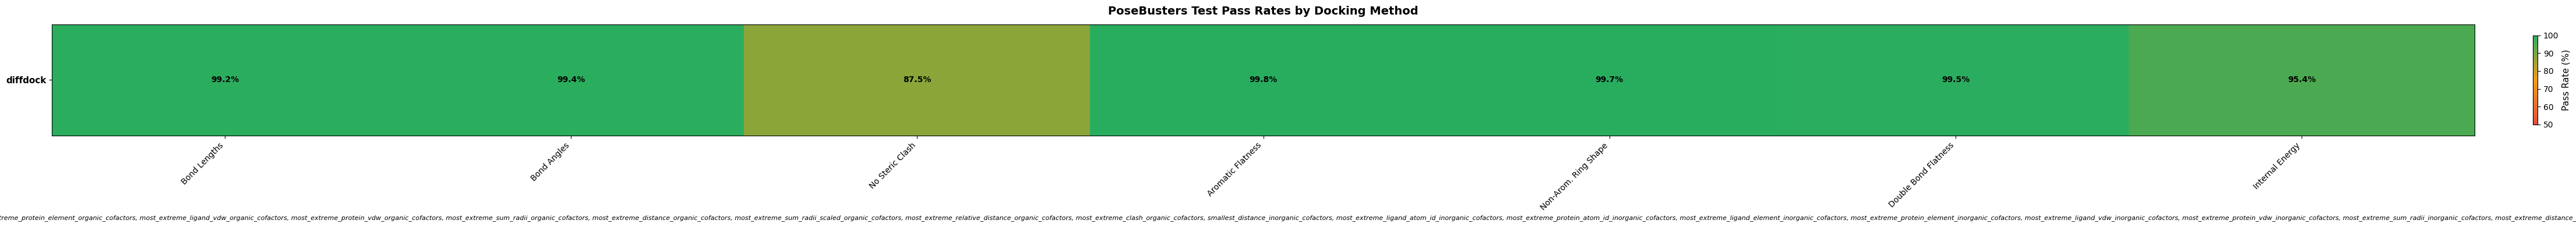

ValueError: Item wrong length 2 instead of 1.

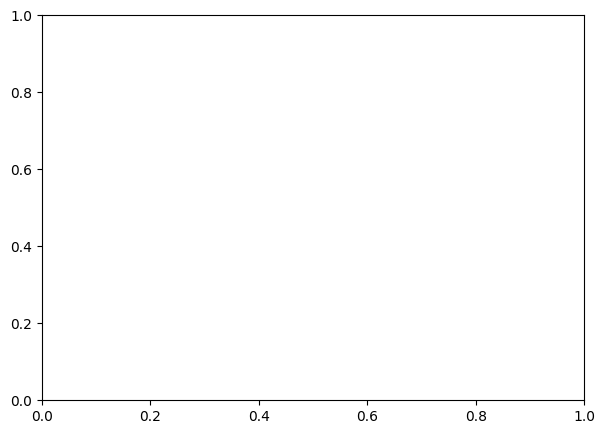

In [22]:
# ============================================================================
# LOAD DATA & IDENTIFY TEST COLUMNS (shared helper)
# ============================================================================
pb_csv = output_dir / "posebusters_filtered_results.csv"
plot_output_dir = output_dir
df = pd.read_csv(pb_csv)

test_cols = identify_test_columns(df)
coerce_test_cols_to_bool(df, test_cols)
df["all_passed"] = df[test_cols].all(axis=1)

TEST_DISPLAY = {
    "mol_pred_loaded": "Molecule Loaded",
    "sanitization": "Sanitization",
    "inchi_convertible": "InChI Convertible",
    "all_atoms_connected": "All Atoms Connected",
    "no_radicals": "No Radicals",
    "bond_lengths": "Bond Lengths",
    "bond_angles": "Bond Angles",
    "internal_steric_clash": "No Steric Clash",
    "aromatic_ring_flatness": "Aromatic Flatness",
    "non-aromatic_ring_non-flatness": "Non-Arom. Ring Shape",
    "double_bond_flatness": "Double Bond Flatness",
    "internal_energy": "Internal Energy",
    "passes_valence_checks": "Valence Checks",
    "passes_kekulization": "Kekulization",
    "no_radicals_before_sanitization": "No Pre-Sanit. Radicals",
}

_COLOR_PALETTE = [
    "#3498db", "#e74c3c", "#2ecc71", "#9b59b6", "#f39c12",
    "#1abc9c", "#e67e22", "#34495e", "#d35400", "#8e44ad",
]
methods = sorted(df["docking_method"].unique())
METHOD_COLORS = {m: _COLOR_PALETTE[i % len(_COLOR_PALETTE)] for i, m in enumerate(methods)}

n_total = len(df)
n_passed = df["all_passed"].sum()
print(f"PoseBusters Results: {n_total} poses, {n_passed} passed all ({n_passed/n_total*100:.1f}%)")
for m in methods:
    g = df[df["docking_method"] == m]
    print(f"  {m}: {g['all_passed'].sum()}/{len(g)} ({g['all_passed'].mean()*100:.1f}%)")

# ============================================================================
# FIGURE 1: Pass rate heatmap (methods × tests)
# ============================================================================
variable_tests = [t for t in test_cols if df[t].mean() < 1.0]
trivial_tests = [t for t in test_cols if t not in variable_tests]

pass_rates = df.groupby("docking_method")[test_cols].mean() * 100
pass_rates_var = pass_rates[variable_tests] if variable_tests else pass_rates

fig1, ax1 = plt.subplots(figsize=(max(10, len(test_cols) * 0.8), max(4, len(methods) * 0.8)))
cmap = LinearSegmentedColormap.from_list("ryg", ["#e74c3c", "#f39c12", "#27ae60"])
im = ax1.imshow(pass_rates_var.values, cmap=cmap, aspect="auto", vmin=50, vmax=100)
ax1.set_yticks(range(len(pass_rates_var.index)))
ax1.set_yticklabels(pass_rates_var.index, fontsize=11, fontweight="bold")
ax1.set_xticks(range(len(pass_rates_var.columns)))
ax1.set_xticklabels(
    [TEST_DISPLAY.get(c, c.replace("_", " ").title()) for c in pass_rates_var.columns],
    rotation=45, ha="right", fontsize=10,
)
for i in range(pass_rates_var.shape[0]):
    for j in range(pass_rates_var.shape[1]):
        val = pass_rates_var.values[i, j]
        ax1.text(j, i, f"{val:.1f}%", ha="center", va="center", fontsize=10,
                 fontweight="bold", color="white" if val < 75 else "black")
cbar = plt.colorbar(im, ax=ax1, shrink=0.8, pad=0.02)
cbar.set_label("Pass Rate (%)", fontsize=11)
if trivial_tests:
    ax1.set_xlabel(
        f"Tests at 100% (not shown): {', '.join(TEST_DISPLAY.get(t, t) for t in trivial_tests)}",
        fontsize=8, style="italic",
    )
ax1.set_title("PoseBusters Test Pass Rates by Docking Method", fontsize=14, fontweight="bold", pad=12)
fig1.tight_layout()
fig1.savefig(plot_output_dir / "pb_passrate_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

# ============================================================================
# FIGURE 2: Stacked bar — pass / fail per method
# ============================================================================
fig2, ax2 = plt.subplots(figsize=(max(7, len(methods) * 2), 5))
counts = df.groupby("docking_method")["all_passed"].value_counts().unstack(fill_value=0)
for val in [True, False]:
    if val not in counts.columns:
        counts[val] = 0
counts = counts[[True, False]].rename(columns={True: "Passed All", False: "Failed >=1"})

ax2.bar(range(len(counts)), counts["Passed All"],
        color=[METHOD_COLORS.get(m, "#888") for m in counts.index],
        edgecolor="white", linewidth=1.5, label="Passed All Tests")
ax2.bar(range(len(counts)), counts["Failed >=1"], bottom=counts["Passed All"],
        color=[METHOD_COLORS.get(m, "#888") for m in counts.index],
        alpha=0.3, edgecolor="white", linewidth=1.5, hatch="///", label="Failed >=1 Test")
for i, (m, row) in enumerate(counts.iterrows()):
    total = row.sum()
    pct = row["Passed All"] / total * 100
    ax2.text(i, total + 5, f'{int(row["Passed All"])}/{int(total)}\n({pct:.1f}%)',
             ha="center", va="bottom", fontsize=11, fontweight="bold")
ax2.set_xticks(range(len(counts)))
ax2.set_xticklabels(counts.index, fontsize=12, fontweight="bold")
ax2.set_ylabel("Number of Poses", fontsize=12)
ax2.set_title("PoseBusters Validation Summary by Docking Method", fontsize=14, fontweight="bold")
ax2.legend(loc="upper right", fontsize=10)
ax2.set_ylim(0, counts.sum(axis=1).max() * 1.25)
ax2.grid(axis="y", alpha=0.3)
fig2.tight_layout()
fig2.savefig(plot_output_dir / "pb_pass_fail_bars.png", dpi=200, bbox_inches="tight")
plt.show()

# ============================================================================
# FIGURE 3: Per-test failure rates (grouped bar)
# ============================================================================
if variable_tests:
    fail_rates = (1 - df.groupby("docking_method")[variable_tests].mean()) * 100
    fig3, ax3 = plt.subplots(figsize=(max(10, len(variable_tests) * 1.5), 5))
    x = np.arange(len(variable_tests))
    width = 0.8 / len(methods)
    for i, m in enumerate(methods):
        vals = fail_rates.loc[m].values
        ax3.bar(x + i * width - 0.4 + width / 2, vals, width,
                label=m, color=METHOD_COLORS.get(m, "#888"), edgecolor="white")
        for j, v in enumerate(vals):
            if v > 2:
                ax3.text(x[j] + i * width - 0.4 + width / 2, v + 0.5,
                         f"{v:.1f}%", ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax3.set_xticks(x)
    ax3.set_xticklabels(
        [TEST_DISPLAY.get(c, c.replace("_", " ").title()) for c in variable_tests],
        rotation=40, ha="right", fontsize=10,
    )
    ax3.set_ylabel("Failure Rate (%)", fontsize=12)
    ax3.set_title("PoseBusters Failure Rates by Test and Method", fontsize=14, fontweight="bold")
    ax3.legend(fontsize=10)
    ax3.grid(axis="y", alpha=0.3)
    fig3.tight_layout()
    fig3.savefig(plot_output_dir / "pb_failure_rates.png", dpi=200, bbox_inches="tight")
    plt.show()

# ============================================================================
# FIGURE 4: Per protein-ligand pass rate (faceted by method)
# ============================================================================
n_methods = len(methods)
fig4, axes4 = plt.subplots(1, n_methods, figsize=(6 * n_methods, 5), sharey=True, squeeze=False)
axes4 = axes4.flatten()
for ax, m in zip(axes4, methods):
    sub = df[df["docking_method"] == m]
    combo_pass = sub.groupby(["protein", "ligand"])["all_passed"].mean() * 100
    combo_pass = combo_pass.sort_values(ascending=True)
    labels = [f"{p}\n{l}" for p, l in combo_pass.index]
    colors = [("#27ae60" if v >= 75 else "#f39c12" if v >= 50 else "#e74c3c") for v in combo_pass.values]
    ax.barh(range(len(combo_pass)), combo_pass.values, color=colors, edgecolor="white")
    ax.set_yticks(range(len(combo_pass)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Pass Rate (%)", fontsize=11)
    ax.set_title(m, fontsize=13, fontweight="bold", color=METHOD_COLORS.get(m, "black"))
    ax.set_xlim(0, 105)
    ax.axvline(75, color="gray", linestyle="--", alpha=0.5)
    ax.grid(axis="x", alpha=0.3)
    for i, v in enumerate(combo_pass.values):
        ax.text(v + 1, i, f"{v:.0f}%", va="center", fontsize=9)
fig4.suptitle("PoseBusters Pass Rate by Protein-Ligand Combination", fontsize=14, fontweight="bold")
fig4.tight_layout()
fig4.savefig(plot_output_dir / "pb_pass_by_combo.png", dpi=200, bbox_inches="tight")
plt.show()

# ============================================================================
# FIGURE 5: Distribution of #tests failed (violin + strip)
# ============================================================================
df["n_failed"] = df[test_cols].apply(lambda r: (~r).sum(), axis=1)
fig5, ax5 = plt.subplots(figsize=(max(8, len(methods) * 2.5), 5))
for i, m in enumerate(methods):
    vals = df[df["docking_method"] == m]["n_failed"]
    parts = ax5.violinplot([vals], positions=[i], showmedians=True, widths=0.7)
    for pc in parts["bodies"]:
        pc.set_facecolor(METHOD_COLORS.get(m, "#888"))
        pc.set_alpha(0.4)
    for key in ["cbars", "cmins", "cmaxes", "cmedians"]:
        parts[key].set_color(METHOD_COLORS.get(m, "#888"))
    jitter = np.random.normal(0, 0.08, len(vals))
    ax5.scatter(np.full(len(vals), i) + jitter, vals, s=10, alpha=0.3,
                color=METHOD_COLORS.get(m, "#888"))
ax5.set_xticks(range(len(methods)))
ax5.set_xticklabels(methods, fontsize=12, fontweight="bold")
ax5.set_ylabel("Number of Tests Failed", fontsize=12)
ax5.set_title("Distribution of Failed Tests per Pose", fontsize=14, fontweight="bold")
ax5.set_ylim(-0.5, df["n_failed"].max() + 1)
ax5.grid(axis="y", alpha=0.3)
for i, m in enumerate(methods):
    med = df[df["docking_method"] == m]["n_failed"].median()
    ax5.text(i, med + 0.3, f"median={med:.0f}", ha="center", fontsize=9, fontweight="bold")
fig5.tight_layout()
fig5.savefig(plot_output_dir / "pb_nfailed_violin.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"\nAll figures saved to: {plot_output_dir}")
print("  pb_passrate_heatmap.png  — Test pass rate heatmap")
print("  pb_pass_fail_bars.png    — Pass/fail stacked bars")
print("  pb_failure_rates.png     — Per-test failure rates")
print("  pb_pass_by_combo.png     — Pass rate by protein-ligand")
print("  pb_nfailed_violin.png    — Distribution of #tests failed")